In [36]:
# Limpieza y tranformacion de los datos
#Fecha: 29 de mayo del 2026
#Autor: Miguel Angel Briones Villagrana

In [37]:
import pandas as pd
import numpy as np

In [38]:
import matplotlib.pyplot as plt

In [39]:
import seaborn as sns

In [40]:
# cargamos el dataset crudo/sucio
dfCrudo = pd.read_csv("../Data/dataset_sucio_practica.csv")

In [41]:
dfCrudo

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No


In [42]:
# generar copia de dataframe
dfCrudoCopia = dfCrudo.copy()

In [43]:
dfCrudoCopia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    object 
 2   edad            110 non-null    float64
 3   correo          125 non-null    object 
 4   pais            82 non-null     object 
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    object 
 7   activo          90 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ KB


In [44]:
dfCrudoCopia.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [45]:
dfCrudoCopia.isnull().sum()

id                 0
nombre             9
edad              15
correo             0
pais              43
salario           18
fecha_registro     0
activo            35
dtype: int64

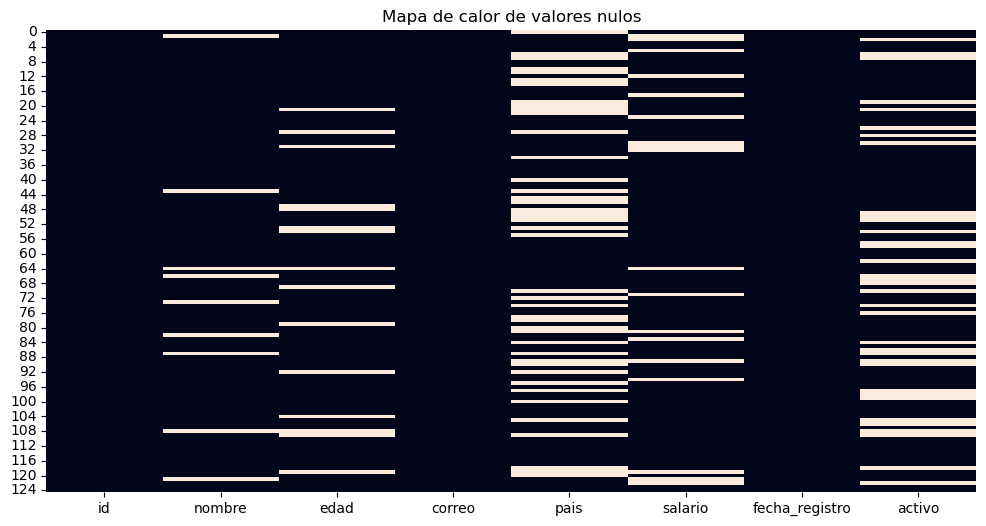

In [46]:
plt.figure ( figsize=(12,6))
sns.heatmap(dfCrudoCopia.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
plt.show()

In [47]:
# eliminamos datos duplicados
dfCrudoCopia.duplicated().sum()

np.int64(5)

In [48]:
dfCrudoCopia.drop_duplicates(inplace=True)

In [49]:
dfCrudoCopia.duplicated().sum()

np.int64(0)

In [50]:
# Mostrar las filas con edades inválidas (menores a 0 o mayores a 100)
dfCrudoCopia[
    (dfCrudoCopia["edad"] < 0) | (dfCrudoCopia["edad"] > 100)
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [51]:
import numpy as np

In [52]:
# 1. Convertimos las edades inválidas en NaN
dfCrudoCopia.loc[
    (dfCrudoCopia["edad"] < 0) | (dfCrudoCopia["edad"] > 100),
    "edad"
] = np.nan

In [53]:
# 2. Calculamos la mediana de la edad (ignora automáticamente los NaN)
media_edad = dfCrudoCopia["edad"].median()

In [54]:
dfCrudoCopia[
(dfCrudoCopia["edad"]<0) | (dfCrudoCopia["edad"]>100)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [55]:
# 2. Calculamos la mediana de la edad (ignora automáticamente los NaN)
media_edad = dfCrudoCopia["edad"].median()
media_edad

30.0

In [56]:
# 3. Rellenamos los valores NaN con el valor de la mediana
dfCrudoCopia["edad"] = dfCrudoCopia["edad"].fillna(media_edad)

In [57]:
# 4. Verificamos que la distribución de edad ahora sea correcta
dfCrudoCopia["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [58]:
#Identificar los salarios negativos

dfCrudoCopia [
(dfCrudoCopia["salario"]<0) ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
9,10,Angela Richards,30.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
11,12,Daniel Wright,25.0,melissamaxwell@gmail.com,NaN,-1000.0,2024-12-20,Sí
20,21,Marc Miller DDS,30.0,ccalderon@campbell-carter.com,NaN,-1000.0,2024-06-25,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
26,27,Mary Miranda,40.0,brendaglenn@gmail.com,Argentina,-1000.0,2025-06-01,NaN
27,28,John Taylor,30.0,jonesashley@hotmail.com,NaN,-1000.0,2025-08-02,No
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
37,38,Brian Sherman,30.0,brianna61@yahoo.com,Argentina,-1000.0,2024-09-17,Sí
41,42,Patricia Morrison,30.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
44,45,John Estrada,35.0,nichole26@hotmail.com,Argentina,-1000.0,2025-12-12,Sí


In [59]:
# Variables de tipo cadena / string / object
dfCrudoCopia[
    ~dfCrudoCopia["correo"].str.contains("@", na=False)
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,correo_invalido,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,correo_invalido,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,correo_invalido,Argentina,NaN,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,correo_invalido,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,correo_invalido,España,-1000.0,2025-12-01,No
78,79,Charles Page,25.0,correo_invalido,NaN,-1000.0,2025-09-01,No
87,88,NaN,22.0,correo_invalido,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,correo_invalido,Argentina,12000.0,2024-11-16,Sí


In [60]:
# CÓDIGO CORREGIDO: Especificando la columna 'correo' para no borrar los demás datos
dfCrudoCopia.loc[
    ~dfCrudoCopia["correo"].str.contains("@", na=False),
    "correo"
] = pd.NA

In [61]:
dfCrudoCopia

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,30.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,<NA>,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,<NA>,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
115,116,Samuel Roth,30.0,robertsmith@taylor.info,España,12000.0,2024-12-10,Sí
116,117,Kristina Buchanan,30.0,rmurphy@gmail.com,Argentina,18000.0,2024-11-18,No
117,118,Michael Harper,30.0,ndaniels@gmail.com,Argentina,12000.0,2026-04-29,No
118,119,Kristopher Hampton,30.0,josephwilliam@taylor-collins.com,NaN,-1000.0,2025-07-08,NaN


In [62]:
correos_ivalidos = ~dfCrudoCopia["correo"].str.contains("@", na=False)
correos_ivalidos

0      False
1      False
2      False
3       True
4       True
       ...  
115    False
116    False
117    False
118    False
119    False
Name: correo, Length: 120, dtype: bool

In [63]:
dfCrudoCopia["correo_valido"] = dfCrudoCopia["correo"].str.contains("@", na=False)

In [64]:
dfCrudoCopia.head(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo,correo_valido
0,1,Julia Zhang,30.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí,True
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No,True
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN,True
3,4,Joyce Williams,30.0,<NA>,Argentina,25000.0,2025-02-23,No,False
4,5,Elaine Sanchez,30.0,<NA>,México,25000.0,2025-03-28,Sí,False


In [65]:
# Revisamos la columna Pais
dfCrudoCopia["pais"].isnull().sum()

np.int64(42)

In [67]:
# Identificamos el pais más repetido
pais_moda = dfCrudoCopia["pais"].mode()[0]

In [68]:
dfCrudoCopia["pais"] = dfCrudoCopia["pais"].fillna(pais_moda)

In [69]:
#Mostramos el total de valores nulos
dfCrudoCopia["pais"].isnull().sum()

np.int64(0)

In [70]:
# verificar tipos de dato 
dfCrudoCopia.dtypes

id                  int64
nombre             object
edad              float64
correo             object
pais               object
salario           float64
fecha_registro     object
activo             object
correo_valido        bool
dtype: object

In [71]:
# Convertimos la fecha registro a DateTime
dfCrudoCopia["fecha_registro"] = pd.to_datetime(dfCrudoCopia["fecha_registro"])

In [72]:
# Mostramos el tipo de dato
dfCrudoCopia["fecha_registro"].dtype

dtype('<M8[ns]')

In [73]:
dfCrudoCopia.dtypes

id                         int64
nombre                    object
edad                     float64
correo                    object
pais                      object
salario                  float64
fecha_registro    datetime64[ns]
activo                    object
correo_valido               bool
dtype: object

In [74]:
# Campo activo
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
Sí     47
No     39
NaN    34
Name: count, dtype: int64

In [75]:
dfCrudoCopia["activo"] = dfCrudoCopia["activo"].fillna("Sí")

In [76]:
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
Sí    81
No    39
Name: count, dtype: int64

In [77]:
# Categorizamos el campo activo
dfCrudoCopia["activo"] = dfCrudoCopia["activo"].map(
    {
        "Sí": 1,
        "No": 0
    }
)

In [78]:
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
1    81
0    39
Name: count, dtype: int64

In [83]:
# Conclusiones

Durante la practica se identificaron y corrigieron las siguientes anomalias:
1. **Valores duplicados**
2. **Valores nulos**
3. **Valores fuera de rango**
4. **Tipos de datos**
5. **Validacion de strings**

SyntaxError: invalid syntax (1674466318.py, line 3)